We will ensure that our identified best models perform better than random models (TF labels permuted) on test data (as assessed by EMD loss). Once confirmed, we will re-train a single model using the "best paramaters" on the training + validation data and assess it's performance on the test data. This is simply for the sake of simplicity, to avoid having 5 models that we are assessing.

In [1]:
import os
import scanpy as sc

import torch
import torch.nn as nn
from geomloss import SamplesLoss

import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.insert(1, '../.')
from Kang_utils import get_best_hyperparams


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [10]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS.model.train import TrainSC
from scLEMBAS import io


In [11]:
seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
models_path = os.path.join(data_path, 'processed', 'models')

In [12]:
adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

In [13]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

Load best models: 

In [14]:
res = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_k_fold_validation_results.csv'), index_col = 0)
best_emd_mean, best_hyperparams, best_emd = get_best_hyperparams(res)

trainers_best = io.read_pickled_object(os.path.join(data_path, 'processed', 'Kang_trainers_k.pickle'))

In [15]:
# sanity check
for k, trainer_k in trainers_best.items():
    trainer_params = [trainer_k.hyper_params['max_epochs'], trainer_k.hyper_params['maximum_learning_rate'], 
             trainer_k.hyper_params['train_batch_size'], trainer_k.hyper_params['vae_scaling_KL']]
    recorded_params = [best_hyperparams['max_epochs'], best_hyperparams['max_lr'], best_hyperparams['train_batch_size'], 
best_emd[best_emd.k == k]['KL_regularization'].tolist()[0]]
    if trainer_params != recorded_params:
        raise ValueError('The stored models do not match the best hyper params')

On each fold, let's train a random model with the same parameters and compare the predictions on the test data with the actual model. We also calculate the loss of the random output vs the actual output, which is equivalent to if the random model had perfect predictions on the random data.

In [137]:
rand_emd_k, actual_emd_k, untrained_rand_emd_k = [], [], []
stim_map = {'STIM': 1, 'CTRL': 0}

test_cells = open(os.path.join(data_path, 'processed', 'data_split_barcodes', 'kang_test.txt')).read().splitlines()

for k, trainer_k in trainers_best.items():
    mod_actual = trainer_k.mod
    
    train_cells = trainer_k.X_train.index.tolist()
    
    # permute the tf labels
    rand_y_out = mod_actual.y_out.copy()
    np.random.seed(seed)
    permuted_tfs = np.random.permutation(rand_y_out.columns)
    rand_y_out = rand_y_out[permuted_tfs]

    # build and train the random model
    mod_rand = SignalingModel(net = sn_ppis,
                         X_in = mod_actual.X_in.copy(),
                         y_out = rand_y_out, 
                         expr = mod_actual.expr.copy(), 
                         covariates = mod_actual.signaling_network.covariates.copy(),
                         categorical_covariate_keys = mod_actual.signaling_network.covariates.columns.tolist(),
                         projection_amplitude_in = mod_actual.input_layer.projection_amplitude, 
                         projection_amplitude_out = mod_actual.projection_amplitude_out,
                         weight_label = weight_label, source_label = source_label, target_label = target_label,
                         bionet_params = mod_actual.signaling_network.bionet_params.copy(), 
                         dtype = torch.float32, device = device, seed = seed)
    mod_rand.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
    mod_rand.signaling_network.prescale_weights(target_radius = mod_actual.signaling_network.bionet_params['spectral_target']) # spectral radius
    
    hyper_params = trainer_k.hyper_params
    hyper_params['validation_batch_size'] = np.nan
    hyper_params['test_batch_size'] = len(test_cells)
    trainer = TrainSC(mod = mod_rand,
                      prediction_optimizer = torch.optim.Adam,
                      prediction_loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device), #torch.nn.MSELoss(reduction='mean'),
                      discriminator_params = trainer_k.discriminator['params'].copy(),
                      hyper_params = hyper_params.copy(),
                  train_split = {'train': train_cells, 'test': test_cells, 'validation': None},
                  train_seed = seed,
                  track_test = False,
                  track_validation = False)

    mod_rand = trainer.train_model(verbose = False)

    # calculate loss on test for each of the actual and random model
    # for each condition: get the test condition predictions from all in-distribution gene expression that was trained
    # take the total loss across conditions
    eme_loss_total_untrained = 0
    emd_loss_total_rand = 0
    emd_loss_total_actual = 0
    for cond in tf_adata.obs.loc[test_cells, :].condition.unique():
        stim, ct = cond.split('^')
        
        test_cells_cond = tf_adata.obs[(tf_adata.obs.index.isin(test_cells)) & (tf_adata.obs['condition'] == cond)].index.tolist()
        y_test = mod_actual.df_to_tensor(tf_adata.to_df().loc[test_cells_cond, :])
        
        # in distribution gene expression!
        expr_test = mod_actual.df_to_tensor(mod_actual.expr.loc[train_cells, :])
        
        # set the stimulation condition we want to predict
        X_test = pd.DataFrame(data = {'IFNB1': [stim_map[stim]]*len(train_cells)})
        X_test = mod_actual.df_to_tensor(X_test)
        
        # set the cell type we want to predict
        cov_idx_map = dict(zip(mod_actual.signaling_network.covariates['seurat_annotations'], 
                               mod_actual.signaling_network.covariates_idx['seurat_annotations']))
        covariates_idx_test = torch.tensor([cov_idx_map[ct]]*len(train_cells), device = mod_actual.device, dtype = torch.int64).view(-1,1)
        
        # random prediction perfect
        loss_fn_untrained = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device)
        y_rand = mod_actual.df_to_tensor(tf_adata.to_df().loc[test_cells_cond, rand_y_out.columns])
        eme_loss_total_untrained += loss_fn_untrained(y_rand, y_test)
        
        # random model trained
        mod_rand.eval()
        with torch.inference_mode():
            y_predicted_rand, _, _ = mod_rand(X_in = X_test, covariates_idx = covariates_idx_test, expr = expr_test)
        loss_fn_rand = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device)
        emd_loss_total_rand += loss_fn_rand(y_predicted_rand, y_test).detach().cpu().item()

        # actual model
        mod_actual.eval()
        with torch.inference_mode():
            y_predicted_actual, _, _ = mod_actual(X_in = X_test, covariates_idx = covariates_idx_test, expr = expr_test)
        loss_fn_actual = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device)
        emd_loss_total_actual += loss_fn_actual(y_predicted_actual, y_test).detach().cpu().item()

        del expr_test, X_test, covariates_idx_test, y_predicted_rand, loss_fn_rand, y_predicted_actual, loss_fn_actual
        del loss_fn_untrained, y_rand
        torch.cuda.empty_cache()
        
    rand_emd_k.append(emd_loss_total_rand)
    actual_emd_k.append(emd_loss_total_actual)
    untrained_rand_emd_k.append(emd_loss_total_untrained)

    k_fold_test = pd.DataFrame(data = {'actual': actual_emd_k, 
                                      'rand': rand_emd_k, 
                                      'perfectly_rand': emd_loss_total_untrained})
    k_fold_test.to_csv(os.path.join(data_path, 'processed', 'k_fold_random.csv'))

Visualize results:

Text(0.5, 0.9, 'MWU p-val: 1.000000')

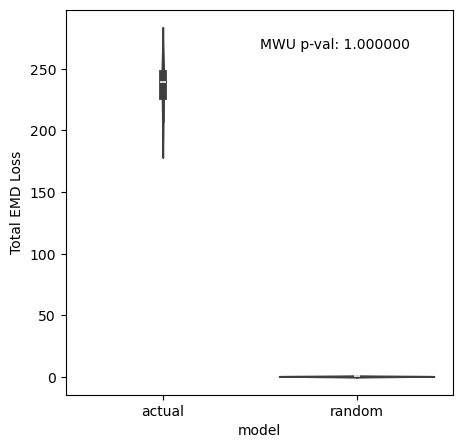

In [180]:
fig, ax = plt.subplots(figsize = (5,5))

pval = mannwhitneyu(k_fold_test.actual, k_fold_test.random, alternative = 'less').pvalue

viz_df = pd.melt(k_fold_test, var_name='model', value_name='Total EMD Loss')

sns.violinplot(data = viz_df, x = 'model', y = 'Total EMD Loss', ax = ax)
ax.annotate('MWU p-val: {:3f}'.format(pval),
            xy=(0.5, 0.9),
            xycoords='axes fraction')